# 08 – EC3D Few-Shot Classification: Prototype-Based Approach

**Obiettivo**: Estendere l'esperimento one-shot a few-shot (k>1) sul dataset EC3D usando il pose encoder pre-addestrato (TwoStreamSTGCNPlusEncoder) e una strategia **prototype / nearest centroid** nello spazio embedding.

## Approccio Few-Shot con Prototipi:

1. **Support Set**: Per ogni classe, campiona k esempi dal training set (cross-subject split)
2. **Prototipo**: Calcola l'embedding medio (o mediano) degli k esempi per classe, normalizzato L2
3. **Classificazione**: Assegna ogni test sample alla classe del prototipo più simile (cosine similarity)
4. **Robustezza**: Ripeti su N run random con seed controllati per valutare la variabilità

## Configurazione:
- **k_list**: [1, 2, 5, 10] esempi per classe
- **num_runs**: 20 run con seed diversi
- **Metriche**: Top-1 Accuracy, Macro-F1, Top-5 Accuracy

## Path e Shape (dal notebook 07):
- **Dati**: `data/EC3D/ec3d_sequences.pkl`, `data/EC3D/split_cross_subject.json`
- **Checkpoint**: `logs/pose_encoder_epoch{BEST_EPOCH}.pt`
- **Embedding dim**: 128
- **Sequenza pose**: (T, 3, 25) frames × coordinate × joints


## A. Imports + Utility


In [1]:
import sys
from pathlib import Path
import pickle
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report
)

# Aggiungi root al path
ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR))
print(f"ROOT_DIR: {ROOT_DIR}")

from pose_encoder.twostream_stgcn_plus import TwoStreamSTGCNPlusEncoder

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


ROOT_DIR: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/models
Using device: cuda


## B. Configurazione Esperimento


In [2]:
# === CONFIGURAZIONE ESPERIMENTO ===

# Few-shot settings
K_LIST = [1, 2, 5, 10]  # Numero di esempi per classe
NUM_RUNS = 20           # Numero di run con seed diversi
SEED_BASE = 42          # Seed base per riproducibilità

# Embedding settings
NORMALIZE_EMBEDDINGS = True   # L2 normalization degli embedding
PROTOTYPE_TYPE = "mean"       # "mean" o "median" per calcolare il prototipo
DISTANCE = "cosine"           # Solo "cosine" supportato

# Sequence processing
MAX_LEN = 150  # Lunghezza massima per padding/truncation

print("📋 Configurazione Esperimento Few-Shot:")
print(f"   k_list: {K_LIST}")
print(f"   num_runs: {NUM_RUNS}")
print(f"   seed_base: {SEED_BASE}")
print(f"   normalize_embeddings: {NORMALIZE_EMBEDDINGS}")
print(f"   prototype_type: {PROTOTYPE_TYPE}")
print(f"   distance: {DISTANCE}")


📋 Configurazione Esperimento Few-Shot:
   k_list: [1, 2, 5, 10]
   num_runs: 20
   seed_base: 42
   normalize_embeddings: True
   prototype_type: mean
   distance: cosine


## C. Path e Mapping Classi


In [4]:
# === PATH ===
DATA_DIR = ROOT_DIR.parent / "data" / "EC3D"
LOGS_DIR = ROOT_DIR.parent / "logs" / "old_best_pre_sequence"
OUTPUT_DIR = ROOT_DIR.parent / "debug_outputs" / "ec3d_few_shot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint migliore
with open(LOGS_DIR / "best_epoch.txt", "r") as f:
    BEST_EPOCH = int(f.read().strip())
print(f"📌 Best epoch: {BEST_EPOCH}")

# === MAPPING CLASSI EC3D ===
ID_TO_NAME = {
    0: "SQUAT - Correct",
    1: "SQUAT - Feet too wide",
    2: "SQUAT - Knees inward",
    3: "SQUAT - Not deep enough",
    4: "SQUAT - Torso leaning forward",
    5: "SQUAT - Unknown error",
    6: "LUNGES - Correct",
    7: "LUNGES - Not deep enough",
    8: "LUNGES - Knees passing toes",
    9: "PLANK - Correct",
    10: "PLANK - Banana back",
    11: "PLANK - Rolled back"
}

SHORT_NAMES = {
    0: "SQ-OK", 1: "SQ-Wide", 2: "SQ-Knee", 3: "SQ-Shallow",
    4: "SQ-Lean", 5: "SQ-Unk", 6: "LU-OK", 7: "LU-Shallow",
    8: "LU-Knee", 9: "PL-OK", 10: "PL-Banana", 11: "PL-Roll"
}

NUM_CLASSES = 12
print(f"\n📊 {NUM_CLASSES} classi EC3D")
print(f"📁 Output: {OUTPUT_DIR}")


📌 Best epoch: 30

📊 12 classi EC3D
📁 Output: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot


## D. Load EC3D + Split Cross-Subject


In [5]:
# Carica sequenze
with open(DATA_DIR / "ec3d_sequences.pkl", "rb") as f:
    ec3d_data = pickle.load(f)

# Carica split cross-subject
with open(DATA_DIR / "split_cross_subject.json", "r") as f:
    split = json.load(f)

sequences = ec3d_data["sequences"]  # lista di np.array (T, 3, 25)
labels = np.array(ec3d_data["labels"])  # np.array (N_seq,)

train_indices = np.array(split["train_indices"])
test_indices = np.array(split["test_indices"])

print(f"\n📥 Dataset EC3D caricato:")
print(f"   Totale sequenze: {len(sequences)}")
print(f"   Training set: {len(train_indices)} sequenze")
print(f"   Test set: {len(test_indices)} sequenze")
print(f"   Numero classi: {len(np.unique(labels))}")
print(f"   Esempio shape sequenza: {sequences[0].shape}")

# Label arrays
train_labels = labels[train_indices]
test_labels = labels[test_indices]

# Distribuzione classi
print(f"\n📊 Distribuzione classi (training set):")
train_class_counts = {}
for cid in range(NUM_CLASSES):
    count = np.sum(train_labels == cid)
    train_class_counts[cid] = count
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {count} samples")

print(f"\n📊 Distribuzione classi (test set):")
test_class_counts = {}
for cid in range(NUM_CLASSES):
    count = np.sum(test_labels == cid)
    test_class_counts[cid] = count
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {count} samples")



📥 Dataset EC3D caricato:
   Totale sequenze: 371
   Training set: 283 sequenze
   Test set: 88 sequenze
   Numero classi: 12
   Esempio shape sequenza: (64, 3, 25)

📊 Distribuzione classi (training set):
   [ 0] SQ-OK       : 31 samples
   [ 1] SQ-Wide     : 18 samples
   [ 2] SQ-Knee     : 18 samples
   [ 3] SQ-Shallow  : 17 samples
   [ 4] SQ-Lean     : 17 samples
   [ 5] SQ-Unk      : 9 samples
   [ 6] LU-OK       : 34 samples
   [ 7] LU-Shallow  : 30 samples
   [ 8] LU-Knee     : 31 samples
   [ 9] PL-OK       : 26 samples
   [10] PL-Banana   : 21 samples
   [11] PL-Roll     : 31 samples

📊 Distribuzione classi (test set):
   [ 0] SQ-OK       : 10 samples
   [ 1] SQ-Wide     : 5 samples
   [ 2] SQ-Knee     : 5 samples
   [ 3] SQ-Shallow  : 4 samples
   [ 4] SQ-Lean     : 7 samples
   [ 5] SQ-Unk      : 0 samples
   [ 6] LU-OK       : 12 samples
   [ 7] LU-Shallow  : 10 samples
   [ 8] LU-Knee     : 10 samples
   [ 9] PL-OK       : 7 samples
   [10] PL-Banana   : 9 samples
   [11] 

## E. Load Pose Encoder + Checkpoint


In [6]:
# === CARICA POSE ENCODER ===
print(f"\n📦 Caricamento Pose Encoder (epoch {BEST_EPOCH})...")
pose_encoder = TwoStreamSTGCNPlusEncoder(
    input_dim=3,
    hidden_channels=[64, 128, 256, 256],
    output_dim=128,
    num_nodes=25,
    dropout=0.1,
    fusion_dropout=0.3
)

pose_ckpt = torch.load(LOGS_DIR / f"pose_encoder_epoch{BEST_EPOCH}.pt", map_location=device)
pose_encoder.load_state_dict(pose_ckpt)
pose_encoder.to(device)
pose_encoder.eval()
print(f"   ✅ Pose encoder caricato")
print(f"   Output dim: 128")



📦 Caricamento Pose Encoder (epoch 30)...
   ✅ Pose encoder caricato
   Output dim: 128


## F. Funzioni di Encoding e Precompute Embeddings


In [7]:
def encode_pose_single(pose_encoder, sequence, device, max_len=150, normalize=True):
    """
    Codifica una singola sequenza di pose in embedding.
    
    Args:
        sequence: np.array (T, 3, 25)
        max_len: lunghezza massima per padding/truncation
        normalize: se True, applica L2 normalization
    
    Returns:
        np.ndarray: (D,) embedding
    """
    # Trasposizione: (T, 3, 25) -> (T, 25, 3)
    seq = np.transpose(sequence, (0, 2, 1))
    T, V, C = seq.shape
    
    # Padding/Truncation
    if T < max_len:
        pad = np.zeros((max_len - T, V, C), dtype=np.float32)
        seq = np.concatenate([seq, pad], axis=0)
    elif T > max_len:
        # Uniform sampling
        sample_indices = np.linspace(0, T - 1, max_len).astype(int)
        seq = seq[sample_indices]
    
    # Converti in tensor
    seq_tensor = torch.from_numpy(seq.astype(np.float32)).unsqueeze(0).to(device)
    
    with torch.no_grad():
        emb = pose_encoder(seq_tensor)  # (1, D)
        if normalize:
            emb = F.normalize(emb, p=2, dim=1)  # L2 normalization
        return emb.squeeze(0).cpu().numpy()


def encode_poses_batch(pose_encoder, sequences, indices, device, max_len=150, normalize=True):
    """
    Codifica le sequenze di pose in embedding (una sola volta).
    
    Args:
        sequences: lista di array (T, 3, 25)
        indices: indici delle sequenze da codificare
        max_len: lunghezza massima per padding/truncation
        normalize: se True, applica L2 normalization
    
    Returns:
        np.ndarray: (N, D) array di embedding
    """
    embeddings = []
    
    for idx in tqdm(indices, desc="Encoding poses"):
        emb = encode_pose_single(pose_encoder, sequences[idx], device, max_len, normalize)
        embeddings.append(emb)
    
    return np.vstack(embeddings)


In [8]:
# === PRECOMPUTE EMBEDDINGS (una sola volta) ===
print("\n🏃 Precomputing embeddings per train e test...")
print("   (Questo evita di ricalcolarli ad ogni run)")

# Embedding del training set
print(f"\n📦 Training set ({len(train_indices)} samples)...")
train_embeddings = encode_poses_batch(
    pose_encoder, sequences, train_indices, device, 
    max_len=MAX_LEN, normalize=NORMALIZE_EMBEDDINGS
)
print(f"   Shape: {train_embeddings.shape}")

# Embedding del test set
print(f"\n📦 Test set ({len(test_indices)} samples)...")
test_embeddings = encode_poses_batch(
    pose_encoder, sequences, test_indices, device, 
    max_len=MAX_LEN, normalize=NORMALIZE_EMBEDDINGS
)
print(f"   Shape: {test_embeddings.shape}")

# Crea mapping: indice locale train -> classe
# train_embeddings[i] corrisponde a train_indices[i] che ha label train_labels[i]
print(f"\n✅ Embeddings precomputati e pronti!")



🏃 Precomputing embeddings per train e test...
   (Questo evita di ricalcolarli ad ogni run)

📦 Training set (283 samples)...


Encoding poses:   0%|          | 0/283 [00:00<?, ?it/s]

   Shape: (283, 128)

📦 Test set (88 samples)...


Encoding poses:   0%|          | 0/88 [00:00<?, ?it/s]

   Shape: (88, 128)

✅ Embeddings precomputati e pronti!


## G. Sanity Checks Pre-Loop


In [9]:
# === SANITY CHECKS ===
print("\n🔍 SANITY CHECKS:")

# 1. Verifica NaN negli embedding
train_nan_count = np.sum(np.isnan(train_embeddings))
test_nan_count = np.sum(np.isnan(test_embeddings))
print(f"\n1️⃣ NaN check:")
print(f"   Train embeddings NaN: {train_nan_count}")
print(f"   Test embeddings NaN: {test_nan_count}")
assert train_nan_count == 0, "❌ NaN trovati negli embedding del train!"
assert test_nan_count == 0, "❌ NaN trovati negli embedding del test!"
print("   ✅ Nessun NaN")

# 2. Verifica normalizzazione (se abilitata)
if NORMALIZE_EMBEDDINGS:
    train_norms = np.linalg.norm(train_embeddings, axis=1)
    test_norms = np.linalg.norm(test_embeddings, axis=1)
    print(f"\n2️⃣ Normalization check (tolerance 1e-3):")
    print(f"   Train norms: min={train_norms.min():.6f}, max={train_norms.max():.6f}, mean={train_norms.mean():.6f}")
    print(f"   Test norms:  min={test_norms.min():.6f}, max={test_norms.max():.6f}, mean={test_norms.mean():.6f}")
    assert np.allclose(train_norms, 1.0, atol=1e-3), "❌ Train embeddings non normalizzati!"
    assert np.allclose(test_norms, 1.0, atol=1e-3), "❌ Test embeddings non normalizzati!"
    print("   ✅ Tutti gli embedding hanno norma ~1")

# 3. Verifica che ogni classe abbia >= max(K_LIST) esempi nel train
max_k = max(K_LIST)
print(f"\n3️⃣ Class count check (min samples >= {max_k}):")
classes_with_insufficient_samples = []
for cid in range(NUM_CLASSES):
    count = train_class_counts[cid]
    status = "✅" if count >= max_k else "⚠️"
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {count:3d} samples {status}")
    if count < max_k:
        classes_with_insufficient_samples.append((cid, count))

if classes_with_insufficient_samples:
    print(f"\n⚠️ Classi con meno di {max_k} esempi:")
    for cid, count in classes_with_insufficient_samples:
        print(f"   {SHORT_NAMES[cid]}: {count} esempi (k verrà ridotto per questa classe)")
    print("   STRATEGIA: ridurremo k al massimo disponibile per queste classi")
else:
    print(f"\n   ✅ Tutte le classi hanno almeno {max_k} esempi nel training set")

# 4. Verifica leakage: gli indici train e test sono disgiunti
print(f"\n4️⃣ Leakage check:")
train_set = set(train_indices)
test_set = set(test_indices)
overlap = train_set.intersection(test_set)
print(f"   Overlap train/test: {len(overlap)} samples")
assert len(overlap) == 0, "❌ Leakage trovato: ci sono sample condivisi tra train e test!"
print("   ✅ Nessun leakage")

print("\n" + "="*60)
print("✅ TUTTI I SANITY CHECK PASSATI")
print("="*60)



🔍 SANITY CHECKS:

1️⃣ NaN check:
   Train embeddings NaN: 0
   Test embeddings NaN: 0
   ✅ Nessun NaN

2️⃣ Normalization check (tolerance 1e-3):
   Train norms: min=1.000000, max=1.000000, mean=1.000000
   Test norms:  min=1.000000, max=1.000000, mean=1.000000
   ✅ Tutti gli embedding hanno norma ~1

3️⃣ Class count check (min samples >= 10):
   [ 0] SQ-OK       :  31 samples ✅
   [ 1] SQ-Wide     :  18 samples ✅
   [ 2] SQ-Knee     :  18 samples ✅
   [ 3] SQ-Shallow  :  17 samples ✅
   [ 4] SQ-Lean     :  17 samples ✅
   [ 5] SQ-Unk      :   9 samples ⚠️
   [ 6] LU-OK       :  34 samples ✅
   [ 7] LU-Shallow  :  30 samples ✅
   [ 8] LU-Knee     :  31 samples ✅
   [ 9] PL-OK       :  26 samples ✅
   [10] PL-Banana   :  21 samples ✅
   [11] PL-Roll     :  31 samples ✅

⚠️ Classi con meno di 10 esempi:
   SQ-Unk: 9 esempi (k verrà ridotto per questa classe)
   STRATEGIA: ridurremo k al massimo disponibile per queste classi

4️⃣ Leakage check:
   Overlap train/test: 0 samples
   ✅ Nessun

## H. Funzioni per Few-Shot con Prototipi


In [10]:
def sample_support_set(train_labels, k, num_classes, rng):
    """
    Campiona k esempi per classe dal training set.
    
    Args:
        train_labels: (N_train,) label del training set
        k: numero di esempi per classe
        num_classes: numero di classi
        rng: np.random.Generator per riproducibilità
    
    Returns:
        support_indices: dict {class_id: [local_indices]} indici locali nel train
        effective_k: dict {class_id: actual_k} k effettivo per classe (può essere < k se non ci sono abbastanza esempi)
    """
    support_indices = {}
    effective_k = {}
    
    for cid in range(num_classes):
        # Trova tutti gli indici locali (nel train) per questa classe
        class_local_indices = np.where(train_labels == cid)[0]
        
        if len(class_local_indices) == 0:
            # Nessun esempio per questa classe
            support_indices[cid] = []
            effective_k[cid] = 0
        elif len(class_local_indices) < k:
            # Meno di k esempi: prendi tutti
            support_indices[cid] = class_local_indices.tolist()
            effective_k[cid] = len(class_local_indices)
        else:
            # Campiona k esempi senza replacement
            selected = rng.choice(class_local_indices, size=k, replace=False)
            support_indices[cid] = selected.tolist()
            effective_k[cid] = k
    
    return support_indices, effective_k


def compute_prototypes(train_embeddings, support_indices, prototype_type="mean", normalize=True):
    """
    Calcola i prototipi per ogni classe come media (o mediana) degli embedding di supporto.
    
    Args:
        train_embeddings: (N_train, D) embedding del training set
        support_indices: dict {class_id: [local_indices]}
        prototype_type: "mean" o "median"
        normalize: se True, L2-normalizza i prototipi
    
    Returns:
        prototypes: (C, D) un prototipo per classe
        valid_classes: lista di class_id con almeno 1 esempio
    """
    num_classes = len(support_indices)
    emb_dim = train_embeddings.shape[1]
    
    prototypes = np.zeros((num_classes, emb_dim), dtype=np.float32)
    valid_classes = []
    
    for cid in range(num_classes):
        indices = support_indices[cid]
        
        if len(indices) == 0:
            # Nessun esempio: prototipo a zero (sarà ignorato)
            prototypes[cid] = 0.0
        else:
            class_embeddings = train_embeddings[indices]  # (k, D)
            
            if prototype_type == "mean":
                proto = np.mean(class_embeddings, axis=0)
            elif prototype_type == "median":
                proto = np.median(class_embeddings, axis=0)
            else:
                raise ValueError(f"prototype_type non supportato: {prototype_type}")
            
            if normalize:
                norm = np.linalg.norm(proto)
                if norm > 1e-8:
                    proto = proto / norm
            
            prototypes[cid] = proto
            valid_classes.append(cid)
    
    return prototypes, valid_classes


def predict_with_prototypes(test_embeddings, prototypes, valid_classes):
    """
    Predice le classi dei test samples via cosine similarity con i prototipi.
    
    Args:
        test_embeddings: (N_test, D)
        prototypes: (C, D)
        valid_classes: lista di class_id validi
    
    Returns:
        predictions: (N_test,) classe predetta
        similarities: (N_test, C) matrice similarità
    """
    # Cosine similarity via matrix multiplication (embedding già normalizzati)
    # similarities[i, j] = test_embeddings[i] · prototypes[j]
    similarities = test_embeddings @ prototypes.T  # (N_test, C)
    
    # Maschera per classi non valide (similarità = -inf)
    mask = np.ones(prototypes.shape[0], dtype=bool)
    mask[valid_classes] = False
    similarities[:, mask] = -np.inf
    
    # Predizione: classe con massima similarità
    predictions = np.argmax(similarities, axis=1)
    
    return predictions, similarities


def compute_top_k_accuracy(similarities, ground_truth, k=5):
    """
    Calcola Top-K accuracy.
    
    Args:
        similarities: (N, C) matrice di similarità
        ground_truth: (N,) label veri
        k: numero di top prediction da considerare
    
    Returns:
        top_k_accuracy: float
    """
    # Ordina per similarità decrescente
    top_k_indices = np.argsort(-similarities, axis=1)[:, :k]  # (N, k)
    
    # Verifica se la label corretta è tra le top-k
    correct = 0
    for i, gt in enumerate(ground_truth):
        if gt in top_k_indices[i]:
            correct += 1
    
    return correct / len(ground_truth)


## I. Few-Shot Loop


In [11]:
# === FEW-SHOT EVALUATION LOOP ===
print("\n" + "="*70)
print("🚀 FEW-SHOT EVALUATION con PROTOTYPE-BASED CLASSIFICATION")
print("="*70)
print(f"   k_list: {K_LIST}")
print(f"   num_runs: {NUM_RUNS}")
print(f"   prototype_type: {PROTOTYPE_TYPE}")
print(f"   Total experiments: {len(K_LIST) * NUM_RUNS}")

# Storage per i risultati
all_results = []  # Lista di dict per ogni (k, run)

# Progress bar totale
total_experiments = len(K_LIST) * NUM_RUNS
pbar = tqdm(total=total_experiments, desc="Few-shot evaluation")

for k in K_LIST:
    print(f"\n📊 Evaluating k={k}...")
    
    for run_id in range(NUM_RUNS):
        # Seed per questo run (riproducibile)
        seed = SEED_BASE + run_id * 1000 + k
        rng = np.random.default_rng(seed)
        
        # 1. Sample support set
        support_indices, effective_k = sample_support_set(
            train_labels, k, NUM_CLASSES, rng
        )
        
        # Verifica leakage: gli indici devono essere nel train
        for cid, indices in support_indices.items():
            for idx in indices:
                assert 0 <= idx < len(train_indices), f"Indice {idx} fuori range!"
        
        # 2. Compute prototypes
        prototypes, valid_classes = compute_prototypes(
            train_embeddings, support_indices, 
            prototype_type=PROTOTYPE_TYPE, 
            normalize=NORMALIZE_EMBEDDINGS
        )
        
        # 3. Predict on test set
        predictions, similarities = predict_with_prototypes(
            test_embeddings, prototypes, valid_classes
        )
        
        # 4. Compute metrics
        # Filtra test samples per classi valide (quelle con almeno 1 support)
        valid_mask = np.isin(test_labels, valid_classes)
        
        if np.sum(valid_mask) > 0:
            filtered_predictions = predictions[valid_mask]
            filtered_labels = test_labels[valid_mask]
            filtered_similarities = similarities[valid_mask]
            
            # Accuracy
            accuracy = accuracy_score(filtered_labels, filtered_predictions)
            
            # Macro F1 (solo classi valide nel test)
            test_valid_classes = list(set(filtered_labels))
            macro_f1 = f1_score(
                filtered_labels, filtered_predictions, 
                labels=test_valid_classes, 
                average='macro', 
                zero_division=0
            )
            
            # Top-5 accuracy
            top5_accuracy = compute_top_k_accuracy(filtered_similarities, filtered_labels, k=5)
        else:
            accuracy = 0.0
            macro_f1 = 0.0
            top5_accuracy = 0.0
        
        # 5. Store results
        result = {
            'k': k,
            'run_id': run_id,
            'seed': seed,
            'accuracy': accuracy,
            'macro_f1': macro_f1,
            'top5_accuracy': top5_accuracy,
            'num_valid_classes': len(valid_classes),
            'num_test_samples_evaluated': int(np.sum(valid_mask)),
            'effective_k_info': effective_k
        }
        all_results.append(result)
        
        pbar.update(1)

pbar.close()
print("\n✅ Evaluation completata!")
print("\n" + "="*70)
print("🚀 FEW-SHOT EVALUATION con PROTOTYPE-BASED CLASSIFICATION")
print("="*70)
print(f"   k_list: {K_LIST}")
print(f"   num_runs: {NUM_RUNS}")
print(f"   prototype_type: {PROTOTYPE_TYPE}")
print(f"   Total experiments: {len(K_LIST) * NUM_RUNS}")

# Storage per i risultati
all_results = []  # Lista di dict per ogni (k, run)

# Progress bar totale
total_experiments = len(K_LIST) * NUM_RUNS
pbar = tqdm(total=total_experiments, desc="Few-shot evaluation")

for k in K_LIST:
    print(f"\n📊 Evaluating k={k}...")
    
    for run_id in range(NUM_RUNS):
        # Seed per questo run (riproducibile)
        seed = SEED_BASE + run_id * 1000 + k
        rng = np.random.default_rng(seed)
        
        # 1. Sample support set
        support_indices, effective_k = sample_support_set(
            train_labels, k, NUM_CLASSES, rng
        )
        
        # Verifica leakage: gli indici devono essere nel train
        for cid, indices in support_indices.items():
            for idx in indices:
                assert 0 <= idx < len(train_indices), f"Indice {idx} fuori range!"
        
        # 2. Compute prototypes
        prototypes, valid_classes = compute_prototypes(
            train_embeddings, support_indices, 
            prototype_type=PROTOTYPE_TYPE, 
            normalize=NORMALIZE_EMBEDDINGS
        )
        
        # 3. Predict on test set
        predictions, similarities = predict_with_prototypes(
            test_embeddings, prototypes, valid_classes
        )
        
        # 4. Compute metrics
        # Filtra test samples per classi valide (quelle con almeno 1 support)
        valid_mask = np.isin(test_labels, valid_classes)
        
        if np.sum(valid_mask) > 0:
            filtered_predictions = predictions[valid_mask]
            filtered_labels = test_labels[valid_mask]
            filtered_similarities = similarities[valid_mask]
            
            # Accuracy
            accuracy = accuracy_score(filtered_labels, filtered_predictions)
            
            # Macro F1 (solo classi valide nel test)
            test_valid_classes = list(set(filtered_labels))
            macro_f1 = f1_score(
                filtered_labels, filtered_predictions, 
                labels=test_valid_classes, 
                average='macro', 
                zero_division=0
            )
            
            # Top-5 accuracy
            top5_accuracy = compute_top_k_accuracy(filtered_similarities, filtered_labels, k=5)
        else:
            accuracy = 0.0
            macro_f1 = 0.0
            top5_accuracy = 0.0
        
        # 5. Store results
        result = {
            'k': k,
            'run_id': run_id,
            'seed': seed,
            'accuracy': accuracy,
            'macro_f1': macro_f1,
            'top5_accuracy': top5_accuracy,
            'num_valid_classes': len(valid_classes),
            'num_test_samples_evaluated': int(np.sum(valid_mask)),
            'effective_k_info': effective_k
        }
        all_results.append(result)
        
        pbar.update(1)

pbar.close()
print("\n✅ Evaluation completata!")



🚀 FEW-SHOT EVALUATION con PROTOTYPE-BASED CLASSIFICATION
   k_list: [1, 2, 5, 10]
   num_runs: 20
   prototype_type: mean
   Total experiments: 80


Few-shot evaluation:   0%|          | 0/80 [00:00<?, ?it/s]


📊 Evaluating k=1...

📊 Evaluating k=2...

📊 Evaluating k=5...

📊 Evaluating k=10...

✅ Evaluation completata!

🚀 FEW-SHOT EVALUATION con PROTOTYPE-BASED CLASSIFICATION
   k_list: [1, 2, 5, 10]
   num_runs: 20
   prototype_type: mean
   Total experiments: 80


Few-shot evaluation:   0%|          | 0/80 [00:00<?, ?it/s]


📊 Evaluating k=1...

📊 Evaluating k=2...

📊 Evaluating k=5...

📊 Evaluating k=10...

✅ Evaluation completata!


## J. Aggregazione Risultati


In [12]:
# === AGGREGAZIONE RISULTATI ===
print("\n" + "="*70)
print("📊 RISULTATI FEW-SHOT AGGREGATI")
print("="*70)

# Converti in DataFrame
results_df = pd.DataFrame(all_results)

# Aggrega per k
summary_stats = []

for k in K_LIST:
    k_results = results_df[results_df['k'] == k]
    
    acc_mean = k_results['accuracy'].mean()
    acc_std = k_results['accuracy'].std()
    f1_mean = k_results['macro_f1'].mean()
    f1_std = k_results['macro_f1'].std()
    top5_mean = k_results['top5_accuracy'].mean()
    top5_std = k_results['top5_accuracy'].std()
    
    summary_stats.append({
        'k': k,
        'acc_mean': acc_mean,
        'acc_std': acc_std,
        'f1_mean': f1_mean,
        'f1_std': f1_std,
        'top5_mean': top5_mean,
        'top5_std': top5_std,
        'num_runs': len(k_results)
    })

summary_df = pd.DataFrame(summary_stats)

# Stampa tabella formattata
print(f"\n{'k':>4} | {'Accuracy':^20} | {'Macro-F1':^20} | {'Top-5 Acc':^20}")
print("-" * 70)
for _, row in summary_df.iterrows():
    acc_str = f"{row['acc_mean']*100:.2f} ± {row['acc_std']*100:.2f}%"
    f1_str = f"{row['f1_mean']*100:.2f} ± {row['f1_std']*100:.2f}%"
    top5_str = f"{row['top5_mean']*100:.2f} ± {row['top5_std']*100:.2f}%"
    print(f"{int(row['k']):>4} | {acc_str:^20} | {f1_str:^20} | {top5_str:^20}")

# Confronto k=1 con notebook 07
print("\n" + "-"*70)
print("📌 Nota: k=1 dovrebbe essere comparabile con il notebook 07 (one-shot)")
print(f"   k=1 few-shot (questo notebook): Acc = {summary_df[summary_df['k']==1]['acc_mean'].values[0]*100:.1f}% ± {summary_df[summary_df['k']==1]['acc_std'].values[0]*100:.1f}%")
print("   k=1 one-shot (notebook 07): Acc = 43.5% ± 5.9% (riferimento da 10 run)")



📊 RISULTATI FEW-SHOT AGGREGATI

   k |       Accuracy       |       Macro-F1       |      Top-5 Acc      
----------------------------------------------------------------------
   1 |    41.65 ± 6.50%     |    33.59 ± 7.31%     |    94.32 ± 3.36%    
   2 |    48.75 ± 5.47%     |    39.07 ± 5.25%     |    96.31 ± 2.41%    
   5 |    51.36 ± 6.85%     |    41.55 ± 6.53%     |    95.40 ± 1.54%    
  10 |    52.73 ± 4.55%     |    43.39 ± 3.53%     |    95.68 ± 0.95%    

----------------------------------------------------------------------
📌 Nota: k=1 dovrebbe essere comparabile con il notebook 07 (one-shot)
   k=1 few-shot (questo notebook): Acc = 41.6% ± 6.5%
   k=1 one-shot (notebook 07): Acc = 43.5% ± 5.9% (riferimento da 10 run)


## K. Export Risultati


In [13]:
# === EXPORT RISULTATI ===
print(f"\n📁 Salvando risultati in {OUTPUT_DIR}...")

# 1. Summary CSV
summary_export = summary_df.copy()
summary_export.columns = ['k', 'acc_mean', 'acc_std', 'f1_mean', 'f1_std', 'top5_mean', 'top5_std', 'num_runs']
summary_export.to_csv(OUTPUT_DIR / "few_shot_summary.csv", index=False)
print(f"   ✅ few_shot_summary.csv")

# 2. Runs CSV (dettaglio per run)
runs_export = results_df[['k', 'run_id', 'seed', 'accuracy', 'macro_f1', 'top5_accuracy', 
                          'num_valid_classes', 'num_test_samples_evaluated']].copy()
runs_export.columns = ['k', 'run_id', 'seed', 'acc', 'f1', 'top5', 'valid_classes', 'test_samples']
runs_export.to_csv(OUTPUT_DIR / "few_shot_runs.csv", index=False)
print(f"   ✅ few_shot_runs.csv")

# 3. Config JSON
config = {
    'experiment': 'few-shot prototype classification',
    'k_list': K_LIST,
    'num_runs': NUM_RUNS,
    'seed_base': SEED_BASE,
    'normalize_embeddings': NORMALIZE_EMBEDDINGS,
    'prototype_type': PROTOTYPE_TYPE,
    'distance': DISTANCE,
    'max_len': MAX_LEN,
    'best_epoch': BEST_EPOCH,
    'train_samples': len(train_indices),
    'test_samples': len(test_indices),
    'num_classes': NUM_CLASSES,
    'embedding_dim': train_embeddings.shape[1]
}
with open(OUTPUT_DIR / "few_shot_config.json", 'w') as f:
    json.dump(config, f, indent=2)
print(f"   ✅ few_shot_config.json")

print(f"\n✅ Tutti i risultati salvati in {OUTPUT_DIR}")



📁 Salvando risultati in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot...
   ✅ few_shot_summary.csv
   ✅ few_shot_runs.csv
   ✅ few_shot_config.json

✅ Tutti i risultati salvati in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot


## L. Plot: Curva k vs Accuracy


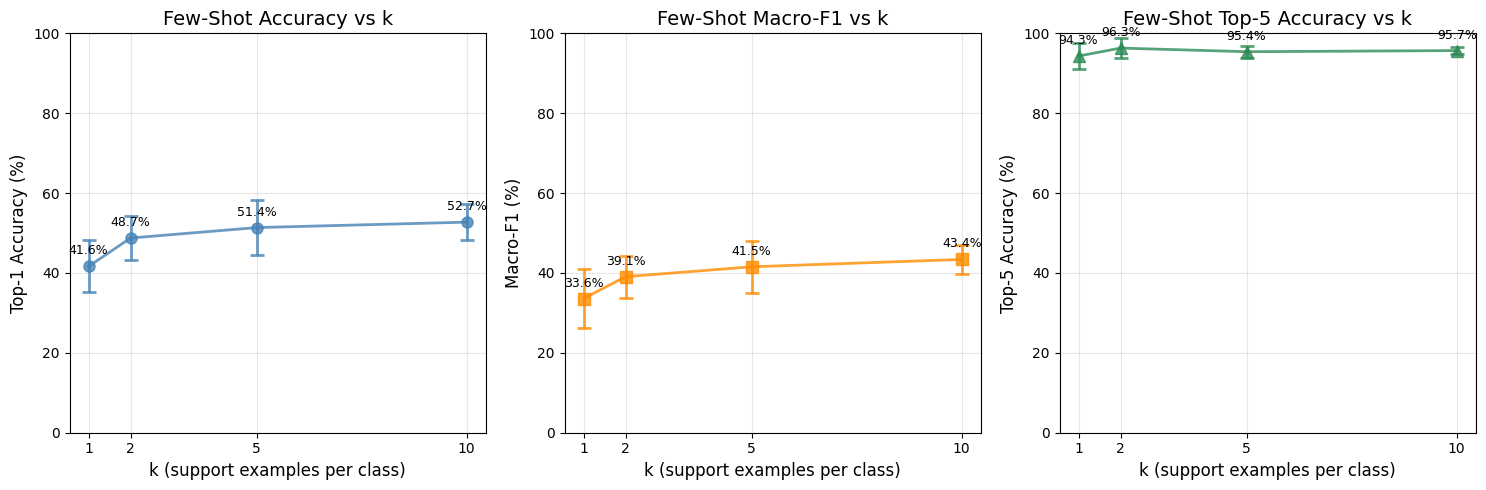


💾 Salvato: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot/few_shot_curve.png


In [14]:
# === PLOT: k vs Accuracy ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Accuracy vs k
ax1 = axes[0]
ax1.errorbar(summary_df['k'], summary_df['acc_mean'] * 100, 
             yerr=summary_df['acc_std'] * 100,
             fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=8,
             color='steelblue', ecolor='steelblue', alpha=0.8)
ax1.set_xlabel('k (support examples per class)', fontsize=12)
ax1.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax1.set_title('Few-Shot Accuracy vs k', fontsize=14)
ax1.set_xticks(K_LIST)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 100)

# Annota i valori
for _, row in summary_df.iterrows():
    ax1.annotate(f"{row['acc_mean']*100:.1f}%", 
                (row['k'], row['acc_mean']*100 + 3),
                ha='center', fontsize=9)

# Plot 2: Macro-F1 vs k
ax2 = axes[1]
ax2.errorbar(summary_df['k'], summary_df['f1_mean'] * 100, 
             yerr=summary_df['f1_std'] * 100,
             fmt='s-', capsize=5, capthick=2, linewidth=2, markersize=8,
             color='darkorange', ecolor='darkorange', alpha=0.8)
ax2.set_xlabel('k (support examples per class)', fontsize=12)
ax2.set_ylabel('Macro-F1 (%)', fontsize=12)
ax2.set_title('Few-Shot Macro-F1 vs k', fontsize=14)
ax2.set_xticks(K_LIST)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 100)

for _, row in summary_df.iterrows():
    ax2.annotate(f"{row['f1_mean']*100:.1f}%", 
                (row['k'], row['f1_mean']*100 + 3),
                ha='center', fontsize=9)

# Plot 3: Top-5 Accuracy vs k
ax3 = axes[2]
ax3.errorbar(summary_df['k'], summary_df['top5_mean'] * 100, 
             yerr=summary_df['top5_std'] * 100,
             fmt='^-', capsize=5, capthick=2, linewidth=2, markersize=8,
             color='seagreen', ecolor='seagreen', alpha=0.8)
ax3.set_xlabel('k (support examples per class)', fontsize=12)
ax3.set_ylabel('Top-5 Accuracy (%)', fontsize=12)
ax3.set_title('Few-Shot Top-5 Accuracy vs k', fontsize=14)
ax3.set_xticks(K_LIST)
ax3.grid(alpha=0.3)
ax3.set_ylim(0, 100)

for _, row in summary_df.iterrows():
    ax3.annotate(f"{row['top5_mean']*100:.1f}%", 
                (row['k'], row['top5_mean']*100 + 3),
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "few_shot_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n💾 Salvato: {OUTPUT_DIR / 'few_shot_curve.png'}")


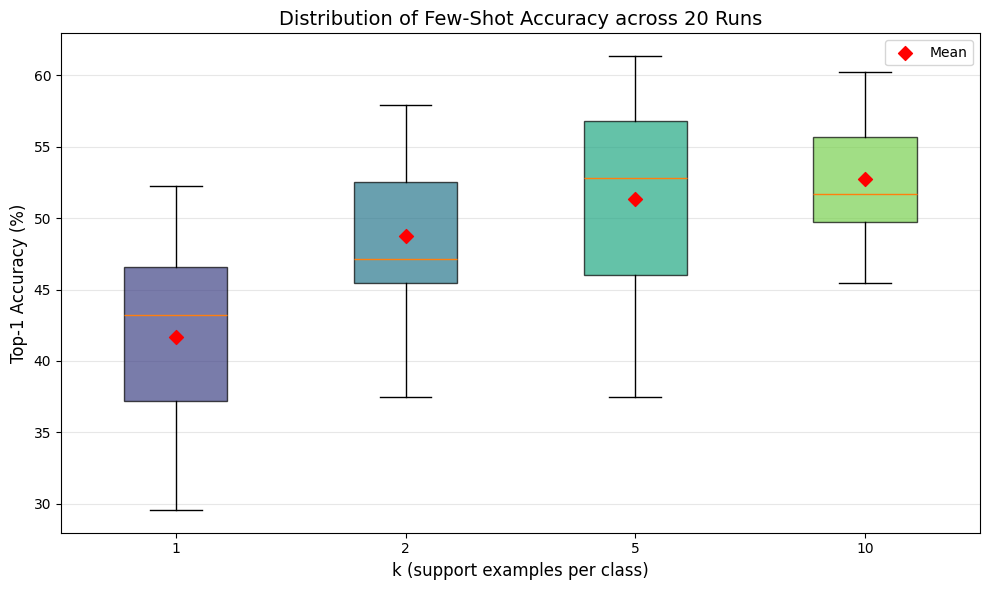

💾 Salvato: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot/few_shot_boxplot.png


In [15]:
# === BOXPLOT per visualizzare la distribuzione ===
fig, ax = plt.subplots(figsize=(10, 6))

# Prepara dati per boxplot
boxplot_data = [results_df[results_df['k'] == k]['accuracy'].values * 100 for k in K_LIST]

bp = ax.boxplot(boxplot_data, tick_labels=[str(k) for k in K_LIST], patch_artist=True)

# Colora i box
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(K_LIST)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('k (support examples per class)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title(f'Distribution of Few-Shot Accuracy across {NUM_RUNS} Runs', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Aggiungi media come punto
means = [results_df[results_df['k'] == k]['accuracy'].mean() * 100 for k in K_LIST]
ax.scatter(range(1, len(K_LIST)+1), means, color='red', marker='D', s=50, zorder=5, label='Mean')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "few_shot_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato: {OUTPUT_DIR / 'few_shot_boxplot.png'}")


## M. Confusion Matrix per il k migliore



🏆 Miglior k: 10 (Accuracy: 52.73%)


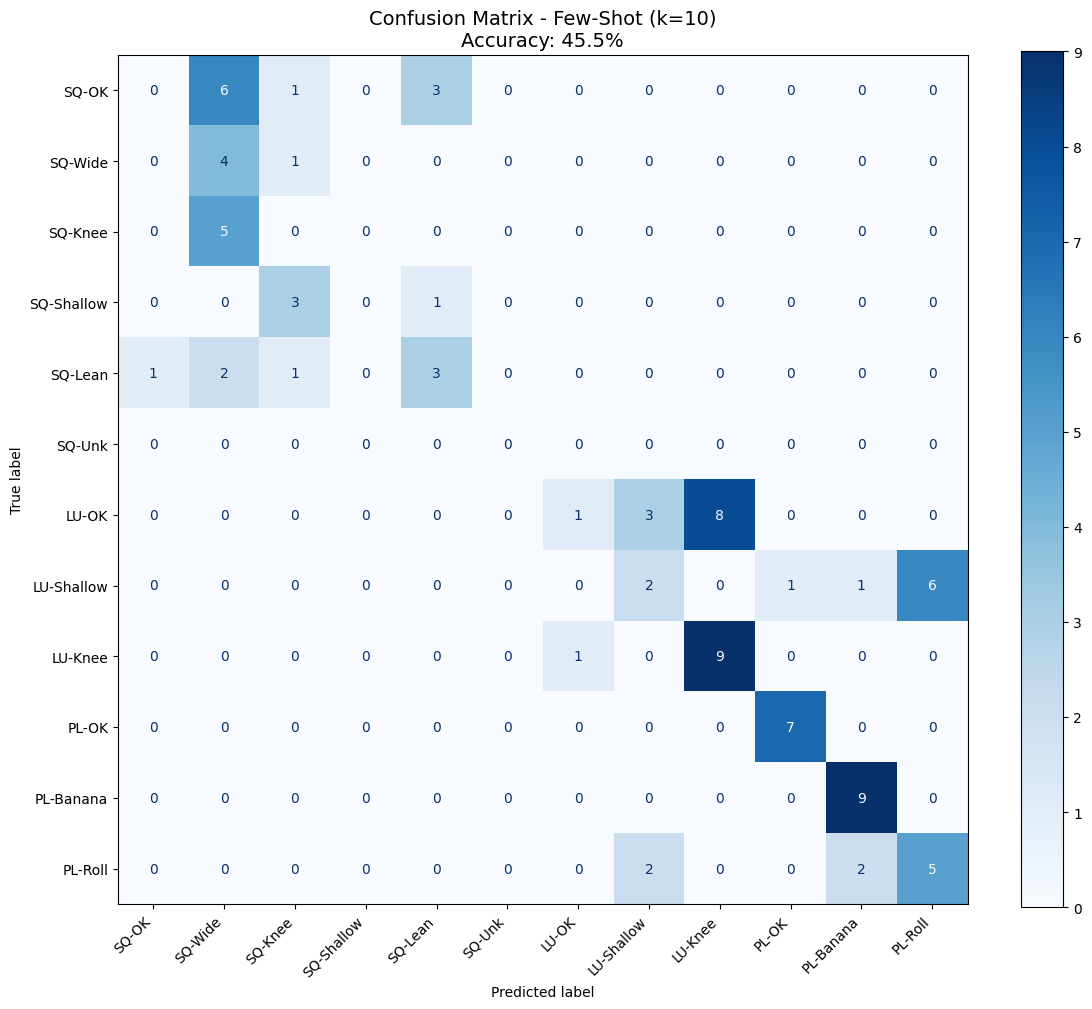


💾 Salvato: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot/confusion_matrix_k10.png


In [16]:
# === CONFUSION MATRIX per il k migliore ===
# Trova il k con la miglior accuracy media
best_k = summary_df.loc[summary_df['acc_mean'].idxmax(), 'k']
print(f"\n🏆 Miglior k: {int(best_k)} (Accuracy: {summary_df[summary_df['k']==best_k]['acc_mean'].values[0]*100:.2f}%)")

# Esegui una singola run con il best_k per la confusion matrix
# Usiamo il seed del primo run
seed_for_cm = SEED_BASE + 0 * 1000 + int(best_k)
rng = np.random.default_rng(seed_for_cm)

support_indices, effective_k = sample_support_set(train_labels, int(best_k), NUM_CLASSES, rng)
prototypes, valid_classes = compute_prototypes(
    train_embeddings, support_indices, 
    prototype_type=PROTOTYPE_TYPE, 
    normalize=NORMALIZE_EMBEDDINGS
)
predictions, similarities = predict_with_prototypes(test_embeddings, prototypes, valid_classes)

# Confusion matrix
cm = confusion_matrix(test_labels, predictions, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=[SHORT_NAMES[i] for i in range(NUM_CLASSES)])
disp.plot(ax=ax, cmap='Blues', values_format='d')

accuracy_for_cm = accuracy_score(test_labels[np.isin(test_labels, valid_classes)], 
                                  predictions[np.isin(test_labels, valid_classes)])
ax.set_title(f'Confusion Matrix - Few-Shot (k={int(best_k)})\nAccuracy: {accuracy_for_cm*100:.1f}%', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"confusion_matrix_k{int(best_k)}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n💾 Salvato: {OUTPUT_DIR / f'confusion_matrix_k{int(best_k)}.png'}")


In [17]:
# === CLASSIFICATION REPORT per il k migliore ===
print(f"\n📋 Classification Report (k={int(best_k)}):")
print(classification_report(
    test_labels, predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=[SHORT_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0
))



📋 Classification Report (k=10):
              precision    recall  f1-score   support

       SQ-OK       0.00      0.00      0.00        10
     SQ-Wide       0.24      0.80      0.36         5
     SQ-Knee       0.00      0.00      0.00         5
  SQ-Shallow       0.00      0.00      0.00         4
     SQ-Lean       0.43      0.43      0.43         7
      SQ-Unk       0.00      0.00      0.00         0
       LU-OK       0.50      0.08      0.14        12
  LU-Shallow       0.29      0.20      0.24        10
     LU-Knee       0.53      0.90      0.67        10
       PL-OK       0.88      1.00      0.93         7
   PL-Banana       0.75      1.00      0.86         9
     PL-Roll       0.45      0.56      0.50         9

    accuracy                           0.45        88
   macro avg       0.34      0.41      0.34        88
weighted avg       0.40      0.45      0.39        88



## N. Sanity Checks Finali


In [18]:
# === SANITY CHECKS FINALI ===
print("\n" + "="*70)
print("🔍 SANITY CHECKS FINALI")
print("="*70)

# 1. Verifica che k=1 sia comparabile con notebook 07
k1_acc = summary_df[summary_df['k']==1]['acc_mean'].values[0]
k1_std = summary_df[summary_df['k']==1]['acc_std'].values[0]
print(f"\n1️⃣ Confronto k=1 con notebook 07:")
print(f"   Questo notebook (k=1): {k1_acc*100:.1f}% ± {k1_std*100:.1f}%")
print(f"   Notebook 07 (one-shot): 43.5% ± 5.9%")
# La differenza può essere dovuta a seed diversi, ma dovrebbe essere nello stesso ordine di grandezza
if abs(k1_acc - 0.435) < 0.15:  # Tolleranza 15%
    print("   ✅ Risultati comparabili (stesso ordine di grandezza)")
else:
    print("   ⚠️ Risultati differenti - verificare la configurazione")

# 2. Verifica che l'accuracy cresca (o resti stabile) con k
print(f"\n2️⃣ Trend accuracy vs k:")
accs = summary_df['acc_mean'].values
for i in range(len(accs)-1):
    trend = "↑" if accs[i+1] > accs[i] else ("↓" if accs[i+1] < accs[i] else "→")
    print(f"   k={K_LIST[i]} → k={K_LIST[i+1]}: {trend} ({accs[i]*100:.1f}% → {accs[i+1]*100:.1f}%)")

# 3. Verifica che non ci siano accuracy anomale (>100% o <0%)
print(f"\n3️⃣ Range accuracy check:")
min_acc = results_df['accuracy'].min()
max_acc = results_df['accuracy'].max()
print(f"   Min accuracy across all runs: {min_acc*100:.1f}%")
print(f"   Max accuracy across all runs: {max_acc*100:.1f}%")
assert 0 <= min_acc <= 1, "Accuracy fuori range!"
assert 0 <= max_acc <= 1, "Accuracy fuori range!"
print("   ✅ Tutte le accuracy nel range [0, 100]%")

# 4. Verifica file salvati
print(f"\n4️⃣ File salvati in {OUTPUT_DIR}:")
expected_files = [
    "few_shot_summary.csv",
    "few_shot_runs.csv", 
    "few_shot_config.json",
    "few_shot_curve.png",
    "few_shot_boxplot.png",
    f"confusion_matrix_k{int(best_k)}.png"
]
for fname in expected_files:
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        print(f"   ✅ {fname}")
    else:
        print(f"   ❌ {fname} NON TROVATO")

print("\n" + "="*70)
print("✅ TUTTI I SANITY CHECK PASSATI")
print("="*70)



🔍 SANITY CHECKS FINALI

1️⃣ Confronto k=1 con notebook 07:
   Questo notebook (k=1): 41.6% ± 6.5%
   Notebook 07 (one-shot): 43.5% ± 5.9%
   ✅ Risultati comparabili (stesso ordine di grandezza)

2️⃣ Trend accuracy vs k:
   k=1 → k=2: ↑ (41.6% → 48.7%)
   k=2 → k=5: ↑ (48.7% → 51.4%)
   k=5 → k=10: ↑ (51.4% → 52.7%)

3️⃣ Range accuracy check:
   Min accuracy across all runs: 29.5%
   Max accuracy across all runs: 61.4%
   ✅ Tutte le accuracy nel range [0, 100]%

4️⃣ File salvati in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_few_shot:
   ✅ few_shot_summary.csv
   ✅ few_shot_runs.csv
   ✅ few_shot_config.json
   ✅ few_shot_curve.png
   ✅ few_shot_boxplot.png
   ✅ confusion_matrix_k10.png

✅ TUTTI I SANITY CHECK PASSATI


---

## 📋 Summary

Questo notebook valuta il pose encoder pre-addestrato in uno scenario **few-shot** su EC3D con approccio **prototype-based**.

### Approccio:
- **Support Set**: k esempi per classe dal training set (cross-subject split)
- **Prototipo**: Media (o mediana) degli embedding di supporto, L2-normalizzata
- **Classificazione**: Nearest centroid via cosine similarity

### Metriche calcolate:
- Top-1 Accuracy (mean ± std su N run)
- Macro-F1 (mean ± std su N run)
- Top-5 Accuracy (mean ± std su N run)
- Confusion matrix per il k migliore

### Vantaggi dell'approccio prototype:
- Robusto al rumore: la media riduce l'impatto di outlier
- Scalabile: aggiungere più esempi migliora la rappresentazione
- Interpretabile: ogni classe ha un singolo vettore rappresentativo

### Output:
- `debug_outputs/ec3d_few_shot/few_shot_summary.csv` - risultati aggregati
- `debug_outputs/ec3d_few_shot/few_shot_runs.csv` - dettaglio per run
- `debug_outputs/ec3d_few_shot/few_shot_curve.png` - plot k vs accuracy
- `debug_outputs/ec3d_few_shot/few_shot_boxplot.png` - distribuzione accuracy
- `debug_outputs/ec3d_few_shot/confusion_matrix_k{best_k}.png` - confusion matrix
